# Random imputation
Random imputation is a method of handling missing data by replacing missing values with randomly selected values from the observed data. This technique can help to preserve the variability in the dataset and can be useful when the missing data is assumed to be missing completely at random (MCAR).
To perform random imputation, you can follow these steps:
1. Identify the missing values in your dataset.
2. For each missing value, randomly select a value from the observed data in the same column. 
3. Replace the missing value with the randomly selected value.


advantages:
- Preserves variability: Random imputation can help to maintain the natural variability in the dataset, which can be beneficial for certain analyses.
- Simple to implement: This method is relatively easy to implement and does not require complex modeling or assumptions about the data.

In [1]:
import numpy as np 
import pandas as pd
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df=pd.read_csv('../../mathematical_transformation/train.csv',usecols=['Age','Fare','Survived'])
df.head()

,Survived,Age,Fare
0,0,22.0,7.2500
1,1,38.0,71.2833
2,1,26.0,7.9250
3,1,35.0,53.1000
4,0,35.0,8.0500


In [4]:
df.isnull().mean()

Survived    0.000000
Age         0.198653
Fare        0.000000
dtype: float64

In [5]:
X=df.drop('Survived',axis=1)
y=df['Survived']

In [6]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=0)

In [7]:
X_train['Age_imputed']=X_train['Age']
X_test['Age_imputed']=X_test['Age']

In [8]:
X_train['Age_imputed'][X_train['Age_imputed'].isnull()]=X_train['Age'].dropna().sample(X_train['Age'].isnull().sum(),random_state=0).values

C:\Users\Lenovo\AppData\Local\Temp\ipykernel_23944\2026079742.py:1: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  X_train['Age_imputed'][X_train['Age_imputed'].isnull()]=X_train['Age'].dropna().sample(X_train['Age'].isnull().sum(),random_sta

In [10]:
X_train.isnull().mean()

Age            0.198034
Fare           0.000000
Age_imputed    0.000000
dtype: float64

C:\Users\Lenovo\AppData\Local\Temp\ipykernel_23944\1657687788.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `kdeplot` (an axes-level function for kernel density plots).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(X_train['Age'],hist=False,label='Original')
C:\Users\Lenovo\AppData\Local\Temp\ipykernel_23944\1657687788.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `kdeplot` (an axes-level function for kernel density plots).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(X_trai

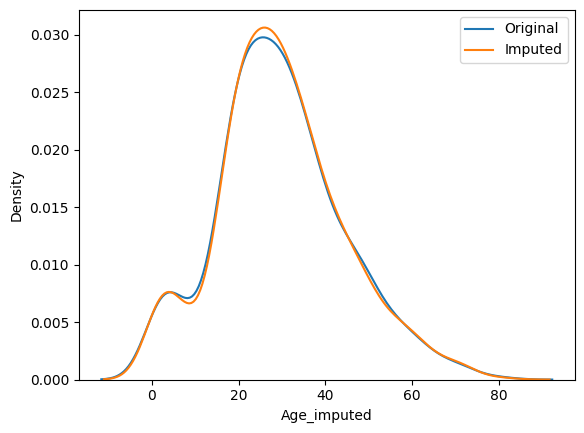

In [11]:
sns.distplot(X_train['Age'],hist=False,label='Original')
sns.distplot(X_train['Age_imputed'],hist=False,label='Imputed')
plt.legend()

In [16]:
print('Original:',X_train['Age'].var())
print('Imputed:',X_train['Age_imputed'].var())

Original: 213.7165085187575
Imputed: 211.19038454147503


In [17]:
data=pd.read_csv('../missing data ctgorical/train (1).csv',usecols=['GarageQual','FireplaceQu','SalePrice'])

In [18]:
data.head()

,FireplaceQu,GarageQual,SalePrice
0,NaN,TA,208500
1,TA,TA,181500
2,TA,TA,223500
3,Gd,TA,140000
4,TA,TA,250000


In [ ]:
X=data
y=data['SalePrice']

In [20]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=0)

In [23]:
X_train['GarageQual_imputed']=X_train['GarageQual']
X_test['GarageQual_imputed']=X_test['GarageQual']
X_train['FireplaceQu_imputed']=X_train['FireplaceQu']
X_test['FireplaceQu_imputed']=X_test['FireplaceQu']

In [26]:
X_train.sample(5)

,FireplaceQu,GarageQual,SalePrice,GarageQual_imputed,FireplaceQu_imputed
789,NaN,TA,187500,TA,NaN
1149,NaN,TA,143000,TA,NaN
890,Po,TA,122900,TA,Po
905,NaN,TA,128000,TA,NaN
102,NaN,TA,118964,TA,NaN


In [ ]:
temp=pd.concat(
    [
        X_train['GarageQual_imputed'].value_counts()/len(X_train['GarageQual_imputed'].dropna()),
        X_train['FireplaceQu_imputed'].value_counts()/len(X_train)
    ],
    axis=1
)

In [29]:
temp

,count,count
TA,0.950450,0.220034
Fa,0.036036,0.024829
Gd,0.009009,0.252568
Po,0.002703,0.014555
Ex,0.001802,0.016267
